## Project overview
 There ia a project from video streaming company. This company recently lossing more customers. The stakeholders have decided to use data science to khow the reason and figure out the solution.

## 1. Define Scope of the project
#### Problem statement:
A video streming company is experiencing a decline in premium subscription, with significant number of customers canceling their subscription plans. The goal is to understand the factors contributing customers churn and develop strategies.

#### Objective and Goals
Analyze customer behaviour and usage pattern to identify main factors contributing customers churn

#### Data requirements
Gender and demographic = Age, sex, location
Usage = How much time they have spent, what are they search, how much time they spent on each video, how many times they open the app in a day (daily active users)
Subscription plan: How frequent they purchase the plan, how many times they come to the subscription landing page
Engagement with add-ons

In [1]:
# import required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv(".//Streaming.csv")
df.sample(5)

,Customer_ID,Age,Gender,Subscription_Length,Region,Payment_Method,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
34,CUST000035,33.0,Female,43,South,PayPal,0,9.0,14.15,149,59.86,0
1354,CUST001355,49.0,Male,49,East,PayPal,1,NaN,5.90,288,59.44,0
4303,CUST004304,39.0,Male,43,South,Debit Card,3,9.0,13.77,331,58.93,1
330,CUST000331,52.0,Female,42,South,PayPal,1,4.0,14.59,196,50.94,0
3174,CUST003175,64.0,Male,12,West,Credit Card,3,NaN,15.20,275,39.92,0


### Remove the features from dataset which are not important

In [6]:
df.drop(columns=['Subscription_Length','Payment_Method'], inplace=True)
df.sample(5)

,Customer_ID,Age,Gender,Region,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
1521,CUST001522,29.0,Male,South,1,7.0,14.89,173,60.50,0
2223,CUST002224,NaN,Female,South,1,4.0,8.89,199,42.73,0
265,CUST000266,43.0,Female,West,0,NaN,16.07,144,45.39,1
3634,CUST003635,34.0,Male,West,2,9.0,19.64,321,62.95,1
4621,CUST004622,NaN,Male,West,1,2.0,7.39,57,31.84,1


### Undersatnd the features datatypes

In [7]:
df.dtypes

Customer_ID                   str
Age                       float64
Gender                        str
Region                        str
Support_Tickets_Raised      int64
Satisfaction_Score        float64
Discount_Offered          float64
Last_Activity               int64
Monthly_Spend             float64
Churned                     int64
dtype: object

1). Change datatype 62-bit to 32-bit where is possible because it consume less resources

## Make decision remove or impute missing values

In [8]:
df.isna().sum()

Customer_ID                 0
Age                       500
Gender                      0
Region                      0
Support_Tickets_Raised      0
Satisfaction_Score        500
Discount_Offered            0
Last_Activity               0
Monthly_Spend               0
Churned                     0
dtype: int64

In [9]:
# percentage of missing columns
df.isna().mean()*100

Customer_ID                0.0
Age                       10.0
Gender                     0.0
Region                     0.0
Support_Tickets_Raised     0.0
Satisfaction_Score        10.0
Discount_Offered           0.0
Last_Activity              0.0
Monthly_Spend              0.0
Churned                    0.0
dtype: float64

check the percentage of missing values is greater than 5-percentage than not delete values

### Imputation

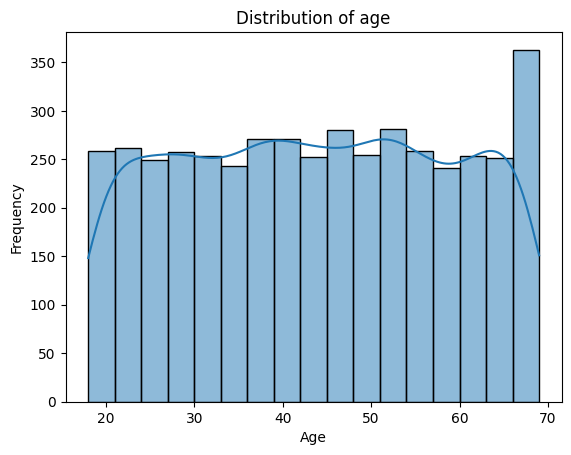

In [11]:
### Check distribution is normal distribution or not
sns.histplot(data=df, kde=True, x=df['Age'].dropna())
plt.title("Distribution of age")
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Decision 
hence distribution is multimodel hence use knn or mice imputers

### KNN INputer vis scikit learn

In [16]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df['Age'] = imputer.fit_transform(df[['Age']])

In [ ]:
!pip install scikit-learn

In [17]:
df.isna().sum()

Customer_ID                 0
Age                         0
Gender                      0
Region                      0
Support_Tickets_Raised      0
Satisfaction_Score        500
Discount_Offered            0
Last_Activity               0
Monthly_Spend               0
Churned                     0
dtype: int64

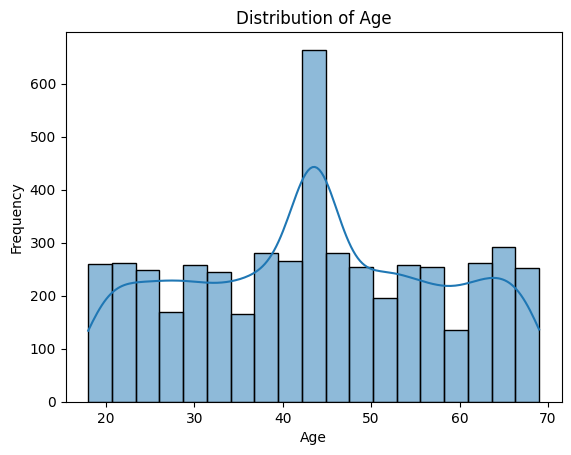

In [19]:
sns.histplot(data=df,kde=True,x=df['Age'])
plt.title("Distribution of Age")
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Using Mice imputer

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer()
df[['Age']] = imputer.fit_transform(df[['Age']])